## SENTIMENT ANALYSIS

In [7]:
from pathlib import Path
import re
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [8]:
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT_DIR / 'data' / 'train.csv'
MODELS_DIR = ROOT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# Loaded with cp1252 to handle unique social media symbols/emojis safely
df = pd.read_csv(DATA_PATH, encoding='cp1252')
# Drop rows where target variable is completely missing
df = df.dropna(subset=['sentiment'])

In [ ]:
def clean_tweet_text(text):
    # Lowercase and strip out hyperlinks/URLs
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    # Remove numbers and punctuation marks
    text = re.sub(r"[^a-z\s]", "", text)
    
    #  Stop-word filtering
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in text.split() if word not in stop_words]
    
    # Lemmatization (reducing words to their base form)
    lemmatizer = WordNetLemmatizer()
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(clean_tokens)

In [11]:
df['clean_text'] = df['text'].apply(clean_tweet_text)

In [12]:
categorical_cols = ['Time of Tweet', 'Age of User', 'Country']
numeric_cols = ['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

X = df[['clean_text'] + categorical_cols + numeric_cols]
y = df['sentiment'].astype(str)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30000), 'clean_text'),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols),
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False))
    ]), numeric_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

In [15]:
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
print('Holdout Accuracy Score:', round(accuracy_score(y_test, predictions), 4))
print('Holdout Macro F1 Score:', round(f1_score(y_test, predictions, average='macro'), 4))
model_file_path = MODELS_DIR / 'logistic_sentiment_pipeline.joblib'
joblib.dump(pipeline, model_file_path)
print(f"Successfully saved clean model pipeline to: {model_file_path}")

Holdout Accuracy Score: 0.6922
Holdout Macro F1 Score: 0.6948
Successfully saved clean model pipeline to: /Users/pawan/Documents/Intenship/Internship Tasks/LearningTask-2/models/logistic_sentiment_pipeline.joblib


In [16]:
y_pred = pipeline.predict(X_test)

metrics_summary = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, y_pred),
    'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}])

In [17]:
print("\n=== HOLDOUT METRICS SUMMARY ===")
print(metrics_summary.to_string(index=False))

print("\n=== DETAILED CLASSIFICATION REPORT ===")
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
print(report_df)

# Generate Confusion Matrix data frame
labels = sorted(y_test.unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'true_{l}' for l in labels], columns=[f'pred_{l}' for l in labels])


=== HOLDOUT METRICS SUMMARY ===
 accuracy  precision_macro  recall_macro  f1_macro  f1_weighted
 0.692196         0.696548      0.693518  0.694786     0.692851

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
negative       0.663317  0.678663  0.670902  1556.000000
neutral        0.658183  0.674460  0.666223  2224.000000
positive       0.768143  0.727432  0.747233  1717.000000
accuracy       0.692196  0.692196  0.692196     0.692196
macro avg      0.696548  0.693518  0.694786  5497.000000
weighted avg   0.693982  0.692196  0.692851  5497.000000


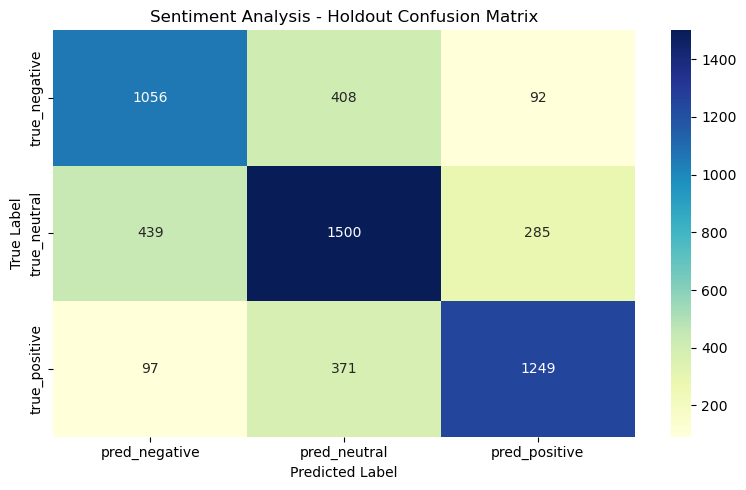

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Sentiment Analysis - Holdout Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

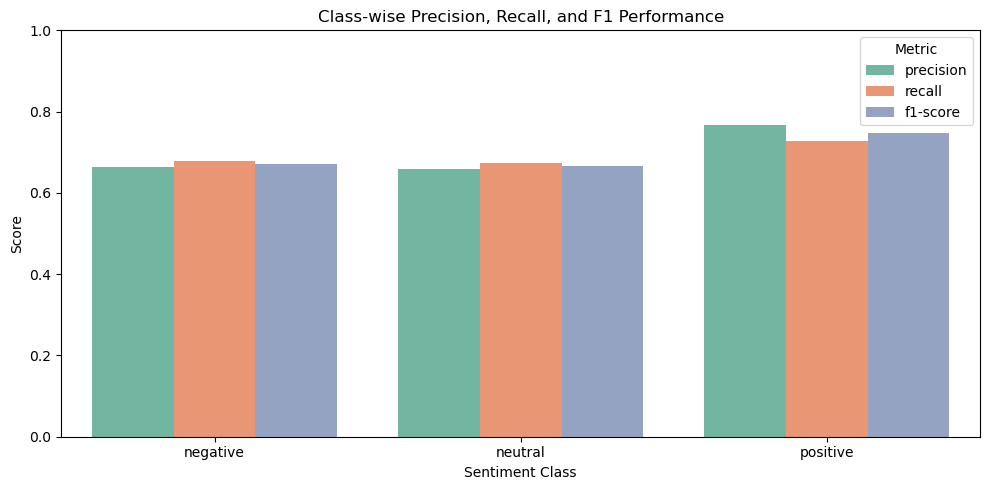

In [19]:
class_rows = [label for label in labels if label in report_df.index]
metrics_plot_df = report_df.loc[class_rows, ['precision', 'recall', 'f1-score']].reset_index()
metrics_plot_df = metrics_plot_df.rename(columns={'index': 'class'})

long_df = metrics_plot_df.melt(id_vars='class', var_name='metric', value_name='score')

plt.figure(figsize=(10, 5))
sns.barplot(data=long_df, x='class', y='score', hue='metric', palette='Set2')
plt.title('Class-wise Precision, Recall, and F1 Performance')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Sentiment Class')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()